# Aufgabenstellung
0. Berechnen Sie während der Vorbereitung auf den Versuch analytisch die Fourier-Transformierten
einer Einzelspalt- und einer Doppelspaltfunktion und vergleichen Sie diese mit den für diese Objekte
bekannten Fraunhofer-Beugungsmustern. Ermitteln Sie mittels FFT (Fast-Fourier-Transform) die
Fourier-Transformierten der Funktionen $F(k) = \text{sinc}(2 \pi k) = \text{sin}(2 \pi k)/(2 \pi k)$ sowie $F(k)^2$. Diskutieren Sie
das Ergebnis unter Berücksichtigung des Faltungstheorems.

1. Messen Sie mit einer CCD-Zeilenkamera das Beugungsbild eines Einzelspalts im Grenzfall der
Fraunhoferbeugung.
Bestimmen Sie die Spaltbreite:
(a) aus der Lage der Minima verschiedener Ordnungen
(b) mittels FFT.

2. Messen Sie mit einer CCD-Zeilenkamera das Beugungsbild eines Doppelspalts im Grenzfall der
Fraunhoferbeugung.
Bestimmen Sie:
(a) den Spaltabstand aus der Lage der Minima verschiedener Ordnungen,
(b) Spaltbreite und Spaltabstand mit einem Fit des bekannten Fraunhofer-
Beugungsbilds an die Daten,
(c) Spaltbreite und Spaltabstand aus der FFT der Intensitätsverteilung.

3. Bestimmen Sie die Talbot-Länge eines Beugungsgitters. Messen Sie dazu mit einer CCD-
Zeilenkamera das Beugungsbild des Beugungsgitters für mehrere Abstände zwischen Kamera und
Gitter. Berechnen Sie die Fouriertransformierte und bestimmen Sie die Intensität des Peaks erster
Ordnung als Funktion des Abstands. Ermitteln Sie aus den Intensitätsoszillationen die Talbot-Länge.
Vergleichen Sie den experimentellen und den theoretischen Wert.

# Aufgabe 0
## Theoretische Grundlagen {#theo-grund}
Für unseren Versuch ist eine Theoretische Grundlage notwendig, die versucht wir in diesem Kapitell zu erlangen.

In diesem Fall ist der Abstand zwischen
Spalt/Doppelspalt und Kamera so groß, dass in guter Näherung ebene Wellen auf die Kamera treffen

Im Fraunhofer-Grenzfall welcher den Tall beschreibt wo der Abstand zwischen Spalt und Kamera so groß ist, dass die Welle in guter näherung als eben betrachtet werden, ist das Beugungsmuster $I(k)$ proportional zum Betrag der Fourier-Transformierten, der Öffnungsfunktion $f(x)$. Diese sind für einen (@eq-einen-spalt) und für zwei Spalten (@eq-zwei-spalten) folgendermaßen definert.
$$f_1(x) = \text{rect}\left(\frac{x}{a}\right)$${#eq-einen-spalt}
$$f_2(x) = \text{rect}\left(\frac{x+d/2}{a}\right) + \text{rect}\left(\frac{x-d/2}{a}\right)$${#eq-zwei-spalten}
Dabei sind für die Öffnungsfunktionen, die Fourier-Transformierten, die folgenden
$$F_1(k) = a ~ \text{sinc}(ka)$${#eq-fft1}
$$F_2(k) = 2a ~ \text{sinc}(ka) ~ \text{cos}(kd/2)$${#eq-fft2}
Nach der Beziehung $I(k) = |F(k)|²$, erhalten wir folgendes Fauenhofer-Beugungsmuster, welches das Intensitätsprofil ist.
$$I_2(k) \propto \text{sinc}²(ka)~\text{cos}²(kd/2)$$

## Vergleich der Einzelspalt- Doppelspaltfunktion mit den bekannten Fraunhoferbeugungsmustern

In [Abbildung #fig-fraunhofer-beugungsmuster] sind die analytischen Fraunhofer-Beugungsmuster zu sehen, für den Einzel- und Doppelspalt.
Dabei sind die geplotteten Funktionen, die Hergeleiteten Fouriertransforamtionen (@eq-fft1) (@eq-fft2), aus dem Kapitel @theo-grund .

Das analytische Fraunhofer-Beugungsmuster des Einzelspalts (blau) entspricht wie sichtbar der Funktion $I(k)=sinc^2(ak)$.

Beim Doppelspalt (orange) überlagern sich zwei Einzelspalte, was zu einer Modulation mit $cos^⁡2(kd/2)$ führt.

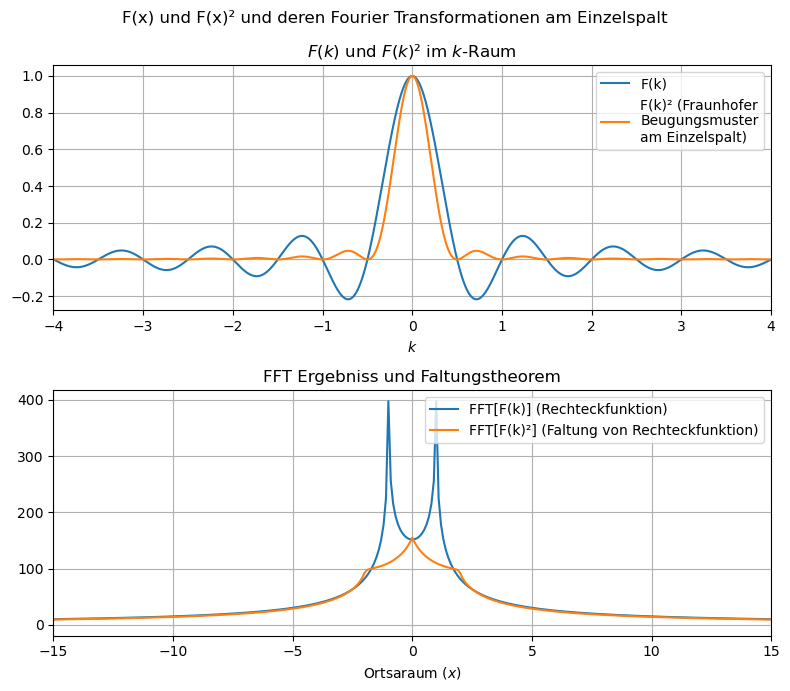

In [1]:
# | label: fig-vergleich
# | fig-cap:
# |     - Die Fourier-Transformierten Formeln, der Einzel-, Doppelspaltfunktion
# |     - Ergebnis der FFT von $F(k)$ und $F(k)²$

import numpy as np
from scipy.fft import fft, fftfreq, fftshift, ifft
import matplotlib.pyplot as plt

# Number of sample points

N = 10000

# sample spacing

T = 1 / 1000

def F(k): #Fraunhofer-Beugungsmuster eines Einzelspalts
    return np.sin(2 * np.pi * k)/(2 * np.pi * k)

x = np.linspace(0.1, N*T, N, endpoint=False)
k = np.linspace(-5, 5, N)
y = F(x)
y_squared = y**2 # Intensität, da I ~ |F|²

yf = fft(y) # Spaltfunktion im Ortraum (numerische FFT)
yf_squared = fft(y_squared) # FFT des Intensitätsmuster -> Faltung im Ortsraum
# damit ds Flatungstheorem erklähren

xf = fftfreq(N, T)

xf_shifted = fftshift(xf)
yf_shifted = fftshift(np.abs(yf))
yf_squared_shifted = fftshift(np.abs(yf_squared))

fig, axs = plt.subplots(2, 1, figsize=(8, 7))
fig.suptitle("F(x) und F(x)² und deren Fourier Transformationen am Einzelspalt")

axs[0].plot(k, F(k), label="F(k)")
axs[0].plot(k, F(k)**2, label="F(k)² (Fraunhofer\nBeugungsmuster\nam Einzelspalt)")
axs[0].set_xlim(-4, 4)
axs[0].grid()
axs[0].set_title("$F(k)$ und $F(k)²$ im $k$-Raum")
axs[0].set_xlabel("$k$")
axs[0].legend()


axs[1].plot(xf_shifted, yf_shifted, label="FFT[F(k)] (Rechteckfunktion)")
axs[1].plot(xf_shifted, yf_squared_shifted, label="FFT[F(k)²] (Faltung von Rechteckfunktion)")
axs[1].set_xlim(-15, 15)
axs[1].grid()
axs[1].set_title("FFT Ergebniss und Faltungstheorem")
axs[1].set_xlabel("Ortsaraum ($x$)")
axs[1].legend()

plt.tight_layout()
plt.show()

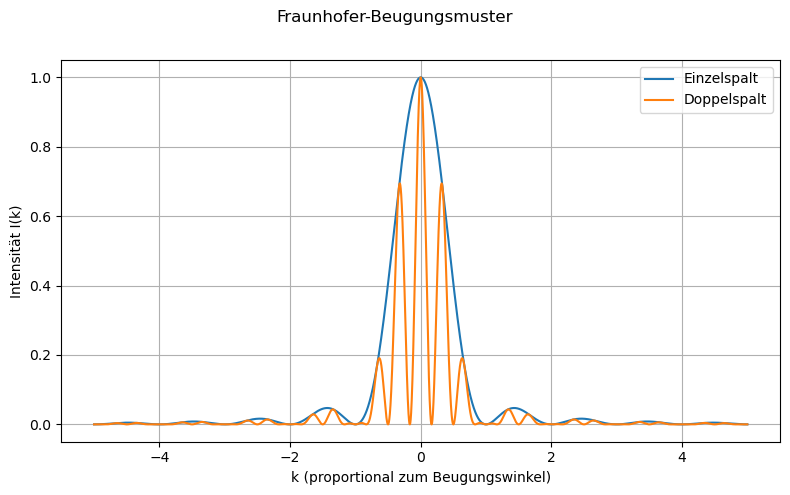

In [ ]:
# | label: fig-fraunhofer-beugungsmuster
# | fig-cap: Vergleich Fraunhofer-Beugungsmuster mit Einzel- und Doppelspalt (analytisch)


# ============================================================
# 1️⃣ Grundparameter
# ============================================================
N = 10000          # Anzahl der Stützstellen
T = 1 / 1000       # Abtastintervall
k = np.linspace(-5, 5, N)  # "Frequenzraum" (k)

# ============================================================
# 2️⃣ Definition der Funktionen
# ============================================================

# Einzelspalt (Fraunhofer-Beugungsmuster)
def F_single(k, a=1.0):
    # sinc(x) = sin(pi*x)/(pi*x) in numpy -> np.sinc(x)
    return np.sinc(a * k)

# Doppelspalt (zwei Spalte mit Abstand d)
def F_double(k, a=1.0, d=3.0):
    return np.sinc(a * k) * np.cos(np.pi * d * k)

# ============================================================
# 3️⃣ Berechnung der Intensitätsverteilungen
# ============================================================
I_single = F_single(k)**2
I_double = F_double(k)**2

# ============================================================
# 4️⃣ FFT-Teil (numerischer Vergleich)
# ============================================================
# Aufgabe: Fourier-Transformierte von F(k) und F(k)^2

def F_func(k):
    return np.sin(2 * np.pi * k) / (2 * np.pi * k)

x = np.linspace(0.1, N*T, N, endpoint=False)
y = F_func(x)
y_squared = y**2

# FFT berechnen
Y_fft = fft(y)
Y_fft_squared = fft(y_squared)
xf = fftfreq(N, T)
xf_shifted = fftshift(xf)
Y_fft_shifted = fftshift(np.abs(Y_fft))
Y_fft_squared_shifted = fftshift(np.abs(Y_fft_squared))

# ============================================================
# 5️⃣ Plot-Ergebnisse
# ============================================================

fig, axs = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle("Vergleich Fraunhofer-Beugungsmuster")

# --- (1) Analytisch: Einzel- und Doppelspalt Fraunhofer-Muster ---
plt.plot(k, I_single, label="Einzelspalt")
plt.plot(k, I_double, label="Doppelspalt")
plt.xlabel("k (proportional zum Beugungswinkel)")
plt.ylabel("Intensität I(k)")
plt.legend()
plt.grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Diskussion unter berücksichtigung des Faltungstheorems
Das Faltungstheorem der Fourier-Transforamtion besagt:
$$FT[f(x) \ \otimes g(x) ] = FT \left[ \int_{- \infty}^{\infty}f(x')g(x-x')dx'\right] = FT[f(x)]FT[g(x)]=F(k)G(k)$$

Dies bedeutet, wenn im $k$-Raum multipliziert wird, wie es bei $F(k)²$ gemacht wurde, dann enspricht das im $x$-Raum eine Faltung der zugehörigen Funktionen.

Genau das kann in [Abbildung #fig-vergleich] beobachtet werden. So ergibt die FFT von $F(k)²$ eine verbreitete Form der ursprünglichen Funktion, welche die Faltung ist.

Somit stimmt, es mit dem Faltungstheorems überein.